In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


In [2]:
data = {
    'Study_Hours': [2,3,4,5,6,7,1,2,8,9,3,5,6,7,4,8,9,1,3,6],
    'Attendance': [60,65,70,75,80,85,50,55,90,95,68,78,82,88,72,91,96,45,62,84],
    'Previous_Score': [50,55,60,65,70,75,45,48,85,90,58,68,73,80,62,87,92,40,52,76],
    'Performance': ['Fail','Fail','Pass','Pass','Pass','Pass','Fail','Fail','Pass','Pass',
                    'Pass','Pass','Pass','Pass','Pass','Pass','Pass','Fail','Fail','Pass']
}
df = pd.DataFrame(data)
df.head()

,Study_Hours,Attendance,Previous_Score,Performance
0,2,60,50,Fail
1,3,65,55,Fail
2,4,70,60,Pass
3,5,75,65,Pass
4,6,80,70,Pass


In [3]:
X = df[['Study_Hours', 'Attendance', 'Previous_Score']]
y = df['Performance']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [4]:
results = []

for depth in [3, 4, 5]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results.append({'max_depth': depth, 'Accuracy': accuracy})

results_df = pd.DataFrame(results)
results_df

,max_depth,Accuracy
0,3,1.0
1,4,1.0
2,5,1.0


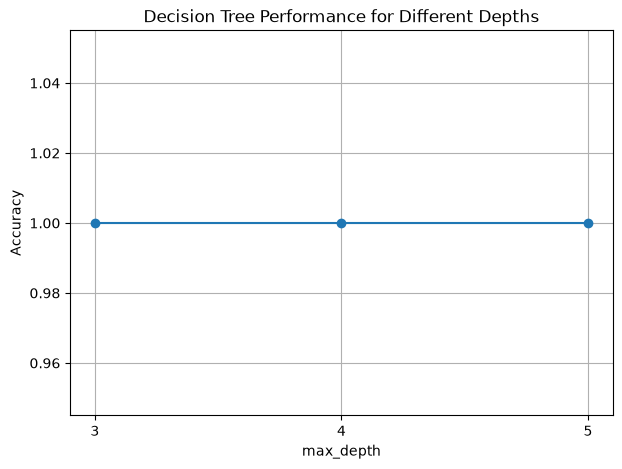

In [5]:
plt.figure(figsize=(7, 5))
plt.plot(results_df['max_depth'], results_df['Accuracy'], marker='o')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Performance for Different Depths')
plt.xticks([3, 4, 5])
plt.grid(True)
plt.show()